In [ ]:
1. Hierarchical Clustering
Concepts: Agglomerative vs divisive, dendrograms

2. DBSCAN
Concepts: Density-based, noise handling

3. Gaussian Mixture Models (GMM)

Concepts: Soft clustering, EM algorithm
Demo: Clustering with GMM vs K-Means


In [ ]:
# Hierarchical Clustering

Concepts
1. Agglomerative (bottom-up): Start with each point as its own cluster, merge step-by-step.
2. Divisive (top-down): Start with one cluster, split recursively.

Dendrograms: A tree-like diagram that shows the merge/split hierarchy. You cut the tree at a threshold to get clusters.

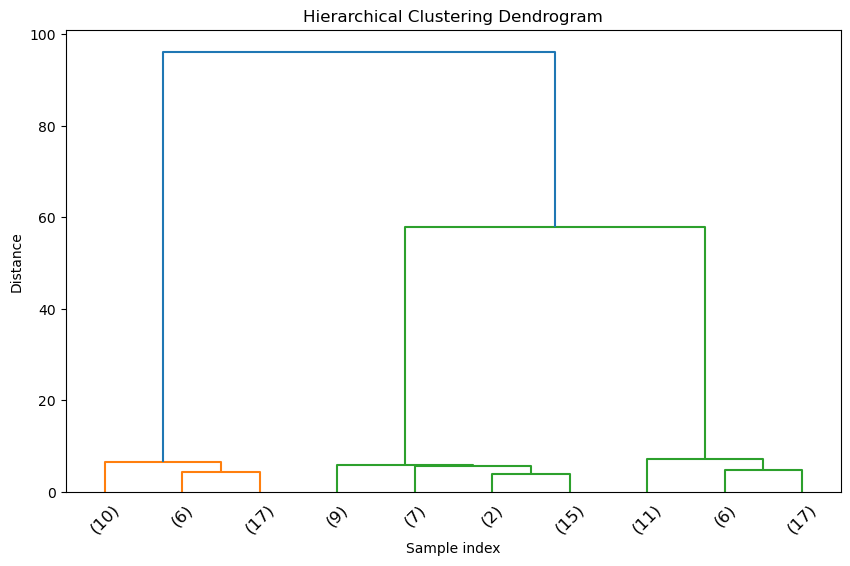

In [1]:
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Generate sample data
X, y = make_blobs(n_samples=100, centers=3, random_state=42)

# Perform hierarchical clustering
linked = linkage(X, method='ward')  # Try 'single', 'complete', 'average'

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=10, leaf_rotation=45.)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

# Extract cluster labels (e.g., 3 clusters)
from scipy.cluster.hierarchy import fcluster
labels = fcluster(linked, 3, criterion='maxclust')


# Agglomerative- Bottom-up (merge pairs of clusters)

In [ ]:
Bottom-Up: Agglomerative Clustering (most common)

1. Starts with each data point as its own cluster
2. Iteratively merges the closest pairs of clusters
3. Continues until all points belong to one big cluster

Think of it like building a pyramid from bricks — you start from the bottom and merge upward.

[1] [2] [3] [4]
 => [1 2] [3] [4]
 => [1 2] [3 4]
 => [1 2 3 4]


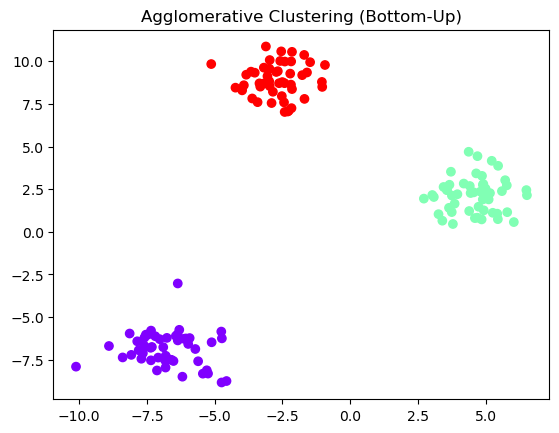

In [3]:
# Agglomerative 

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Generate synthetic data
X, y = make_blobs(n_samples=150, centers=3, random_state=42)

# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg.fit_predict(X)

# Plot result
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("Agglomerative Clustering (Bottom-Up)")
plt.show()


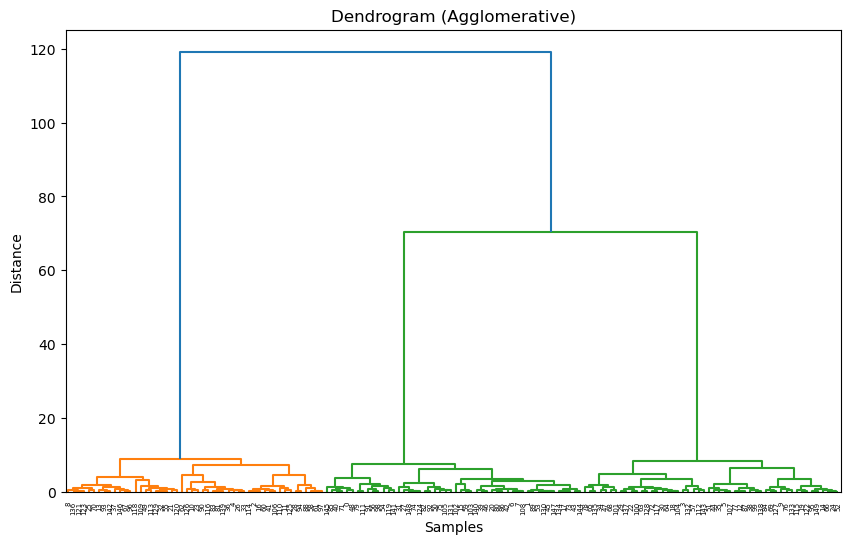

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram (Agglomerative)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


# Divisive - Top-down (split recursively)	

In [ ]:
1. Starts with all points in one cluster
2. Recursively splits the cluster into smaller parts
3. Continues until each point is its own cluster or a stopping condition is met

Think of it like chopping a big tree down into branches
[1 2 3 4]
 => [1 2] [3 4]
 => [1] [2] [3 4]
 => [1] [2] [3] [4]


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


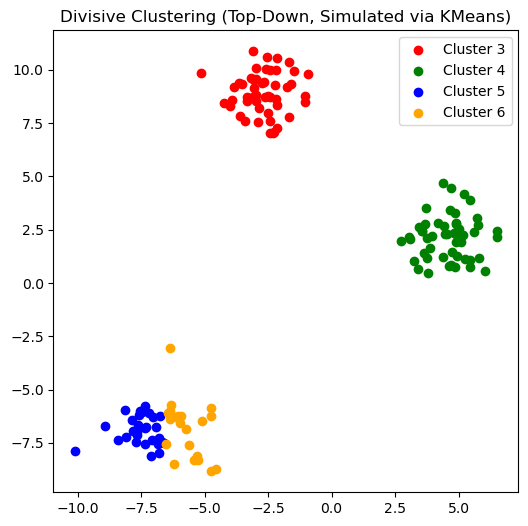

In [5]:
from sklearn.cluster import KMeans
import numpy as np

def divisive_kmeans(X, max_depth=2, depth=0, cluster_label=0):
    labels = np.zeros(len(X), dtype=int)
    
    if depth == max_depth or len(X) <= 2:
        return [(X, cluster_label)]
    
    kmeans = KMeans(n_clusters=2, random_state=42)
    y = kmeans.fit_predict(X)
    
    result = []
    for i in range(2):
        Xi = X[y == i]
        result += divisive_kmeans(Xi, max_depth, depth + 1, cluster_label * 2 + i + 1)
    return result

# Apply divisive clustering
clusters = divisive_kmeans(X, max_depth=2)

# Visualize
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
plt.figure(figsize=(6, 6))
for i, (cluster_data, label) in enumerate(clusters):
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], color=colors[i % len(colors)], label=f'Cluster {label}')
plt.title("Divisive Clustering (Top-Down, Simulated via KMeans)")
plt.legend()
plt.show()


In [8]:
# On a dataset
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Reduce to 2D for visualization
X_pca = PCA(n_components=2).fit_transform(X_scaled)


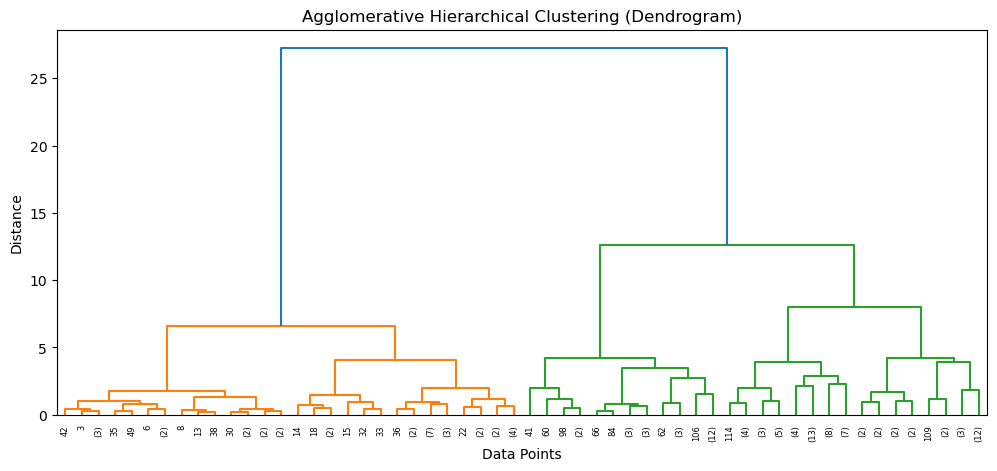

In [9]:

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

# Create linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Agglomerative Hierarchical Clustering (Dendrogram)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


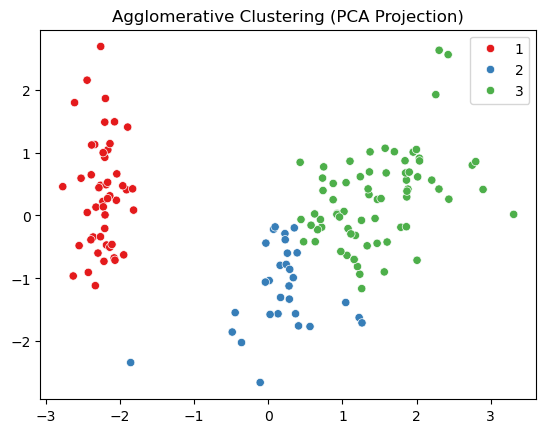

In [10]:
from scipy.cluster.hierarchy import fcluster
labels_agglo = fcluster(Z, t=3, criterion='maxclust')

# Visualize clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agglo, palette='Set1')
plt.title("Agglomerative Clustering (PCA Projection)")
plt.show()


0.3.0


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


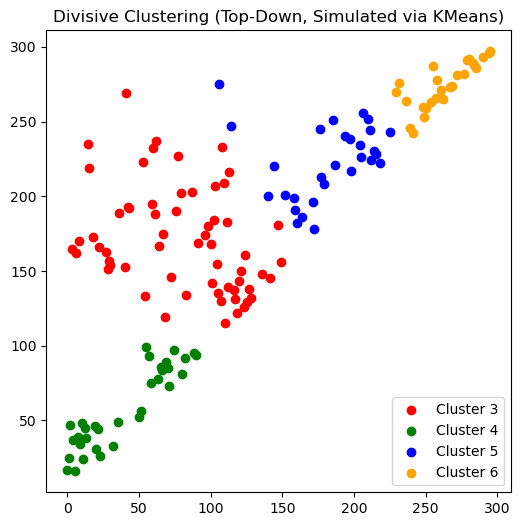

In [16]:
# Apply divisive clustering
clusters = divisive_kmeans(Z, max_depth=2)

# Visualize
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
plt.figure(figsize=(6, 6))
for i, (cluster_data, label) in enumerate(clusters):
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], color=colors[i % len(colors)], label=f'Cluster {label}')
plt.title("Divisive Clustering (Top-Down, Simulated via KMeans)")
plt.legend()
plt.show()

# DBSCAN (Density-Based Spatial Clustering)

In [ ]:
DBSCAN (Density-Based Spatial Clustering)

Concepts
1. Finds dense regions in data.
2. Does not need K as input.
3. Handles noise and arbitrary-shaped clusters.

Parameters: eps (radius), min_samples (minimum points to form a core point).

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


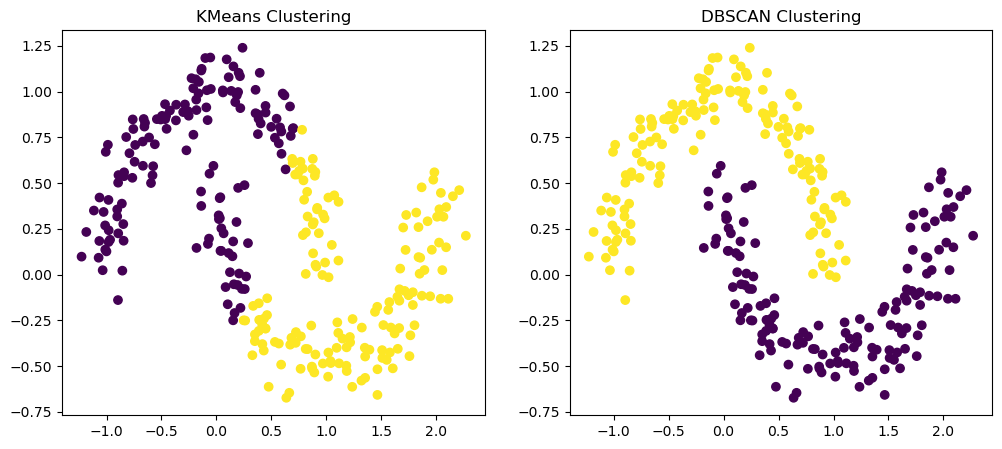

In [2]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# Create noisy crescent data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
k_labels = kmeans.fit_predict(X)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X)

# Plotting results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=k_labels, cmap='viridis')
axes[0].set_title("KMeans Clustering")

axes[1].scatter(X[:, 0], X[:, 1], c=db_labels, cmap='viridis')
axes[1].set_title("DBSCAN Clustering")
plt.show()


In [ ]:
# on a dataset

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r'Mall_Customers.csv')  # path
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
X_scaled = StandardScaler().fit_transform(X)


In [22]:
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

df['DBSCAN_Label'] = labels


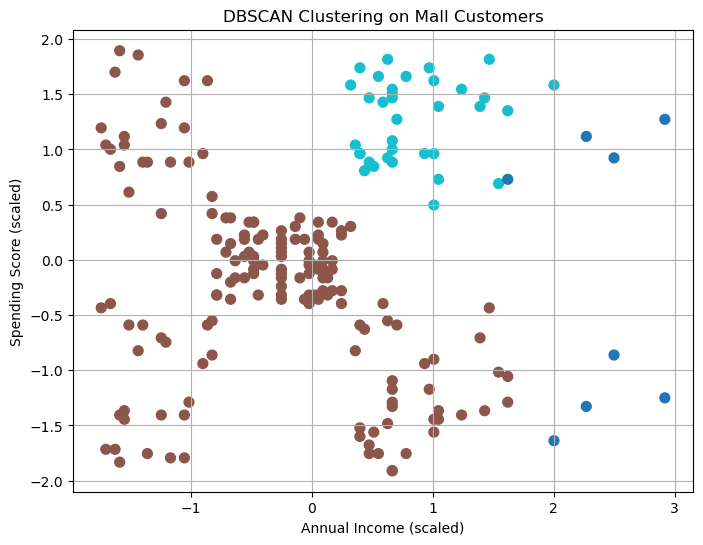

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=labels, cmap='tab10', s=50
)
plt.title('DBSCAN Clustering on Mall Customers')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.grid(True)
plt.show()


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


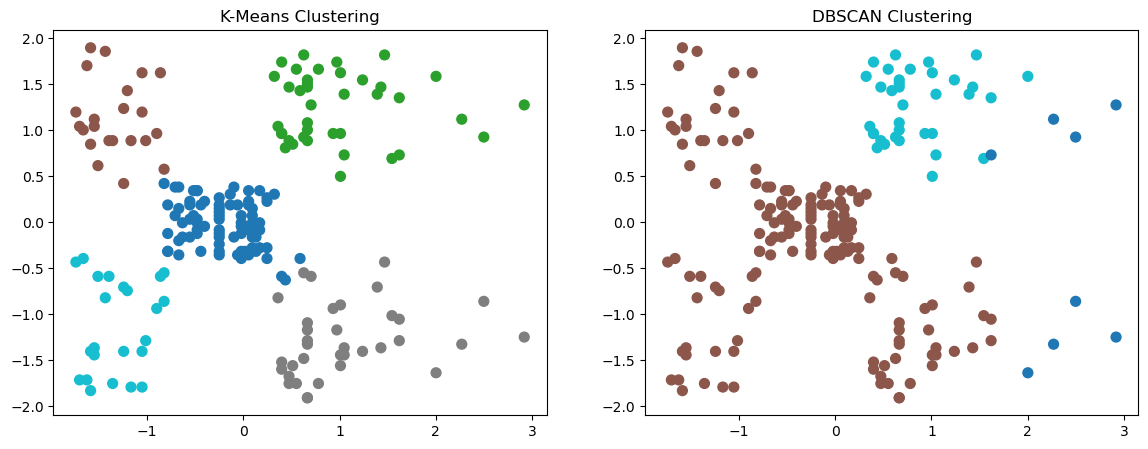

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
k_labels = kmeans.fit_predict(X_scaled)

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_labels, cmap='tab10', s=50)
axs[0].set_title('K-Means Clustering')

axs[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=50)
axs[1].set_title('DBSCAN Clustering')

plt.show()


DBSCAN can find non-convex clusters, automatically detect a suitable number of clusters, and filter out noise.

K-Means, on the other hand, forces clusters into shapes (like circles) and always assigns every point to a group, even outliers

# Gaussian Mixture Models (GMM)
Concepts: Soft clustering, EM algorithm

In [ ]:
A Gaussian Mixture Model (GMM) is a probabilistic model that assumes data is generated from a mixture of several Gaussian distributions 
(also called normal distributions), each representing a different cluster.

Unlike K-Means, which assigns each point to a single cluster (hard assignment), GMM gives a probability (soft assignment) 
that a point belongs to each cluster.


In [ ]:
. Gaussian Distribution

1 Each cluster is modeled as a multivariate Gaussian:
2 Characterized by a mean (μ) and covariance (Σ).
3 Can form elliptical clusters, not just spherical ones like in K-Means.

2. Mixture Model
A mixture of K Gaussian components, each with a weight (π).

For any data point x, the total probability is the weighted sum of the K Gaussians:

P(x) = π₁ * N(x | μ₁, Σ₁) + π₂ * N(x | μ₂, Σ₂) + ... + πK * N(x | μK, ΣK)

3. Expectation-Maximization (EM) Algorithm

1. GMM uses the EM algorithm to find the parameters (means, covariances, and weights):
2. E-Step (Expectation): Calculate the probability that each point belongs to each cluster.
3. M-Step (Maximization): Update the parameters of each Gaussian based on those probabilities.

Repeat until convergence.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [27]:
# Load iris dataset
iris = load_iris()
X = iris.data  # Only features
y_true = iris.target  # True labels (used only for comparison, not in clustering)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
# Fit Gaussian Mixture Model with 3 components
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# Predict cluster labels
gmm_labels = gmm.predict(X_scaled)


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


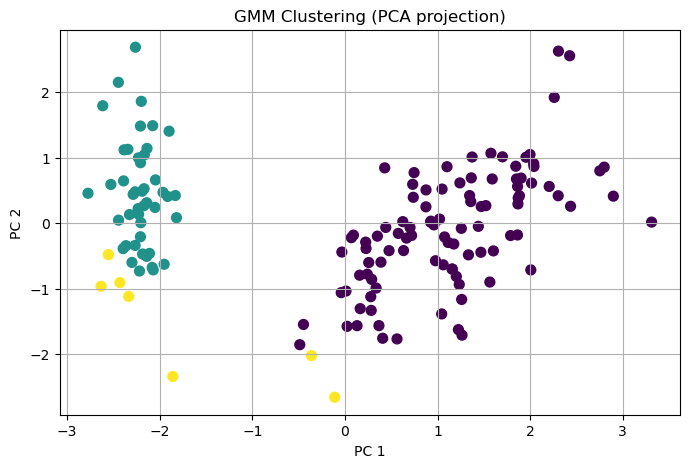

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', s=50)
plt.title("GMM Clustering (PCA projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()


In [30]:
# Probabilities of each point belonging to each cluster
probs = gmm.predict_proba(X_scaled)
print(probs[:5])  # First 5 samples

[[2.74503381e-011 1.00000000e+000 0.00000000e+000]
 [1.16033052e-007 9.99999884e-001 0.00000000e+000]
 [9.72921434e-009 9.99999990e-001 5.88168010e-278]
 [2.02193473e-007 9.99999798e-001 3.33173699e-141]
 [9.67775891e-012 1.00000000e+000 0.00000000e+000]]


In [2]:
# just for visualization purposes
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Generate synthetic data
X, y_true = make_blobs(n_samples=1000, centers=10, cluster_std=1.0, random_state=42)

# Initialize figure
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
titles = ['K-Means Clustering', 'Gaussian Mixture Model']
colors = ['red', 'green', 'blue']

def update(frame):
    ax[0].cla()
    ax[1].cla()

    # Fit KMeans
    kmeans = KMeans(n_clusters=3, max_iter=frame+1, n_init=1, init='random', random_state=42)
    kmeans.fit(X)
    labels_kmeans = kmeans.predict(X)
    centers_kmeans = kmeans.cluster_centers_

    # Plot KMeans
    ax[0].scatter(X[:, 0], X[:, 1], c=[colors[i] for i in labels_kmeans], s=20)
    ax[0].scatter(centers_kmeans[:, 0], centers_kmeans[:, 1], c='black', s=100, marker='x')
    ax[0].set_title(f"{titles[0]} (iter {frame+1})")

    # Fit GMM
    gmm = GaussianMixture(n_components=3, max_iter=frame+1, covariance_type='full', random_state=42)
    gmm.fit(X)
    labels_gmm = gmm.predict(X)
    probs = gmm.predict_proba(X)
    means = gmm.means_

    # Plot GMM
    ax[1].scatter(X[:, 0], X[:, 1], c=[colors[i] for i in labels_gmm], s=20)
    ax[1].scatter(means[:, 0], means[:, 1], c='black', s=100, marker='x')
    ax[1].set_title(f"{titles[1]} (iter {frame+1})")

    for a in ax:
        a.set_xlim(X[:,0].min() - 1, X[:,0].max() + 1)
        a.set_ylim(X[:,1].min() - 1, X[:,1].max() + 1)
        a.set_xticks([])
        a.set_yticks([])

# Animate
anim = FuncAnimation(fig, update, frames=20, interval=500)

# Save animation
anim.save("kmeans_vs_gmm.gif", writer=PillowWriter(fps=2))
plt.close()

print("Animation saved as kmeans_vs_gmm.gif")


C:\Users\harep\anaconda3\envs\ai_env\lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\harep\anaconda3\envs\ai_env\lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\harep\anaconda3\envs\ai_env\lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Animation saved as kmeans_vs_gmm.gif
